In [1]:
#EDA & Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.dpi']       = 130
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['font.size']        = 11

# Load the cleaned dataset
df = pd.read_csv('../data/processed/car_data_cleaned.csv')

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded: 291 rows × 8 columns
Columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [2]:
#Questions must be answered using charts 
eda_questions = {
    "Q1": "How is Selling_Price distributed? Is it skewed?",
    "Q2": "How does Car_Age affect price? (key relationship)",
    "Q3": "Do Fuel_Type / Transmission / Seller_Type affect price?",
    "Q4": "How does Kms_Driven relate to price?",
    "Q5": "Which features are most correlated with Selling_Price?"
}

for q, question in eda_questions.items():
    print(f"{q}: {question}")

Q1: How is Selling_Price distributed? Is it skewed?
Q2: How does Car_Age affect price? (key relationship)
Q3: Do Fuel_Type / Transmission / Seller_Type affect price?
Q4: How does Kms_Driven relate to price?
Q5: Which features are most correlated with Selling_Price?


This is how selling price distributed


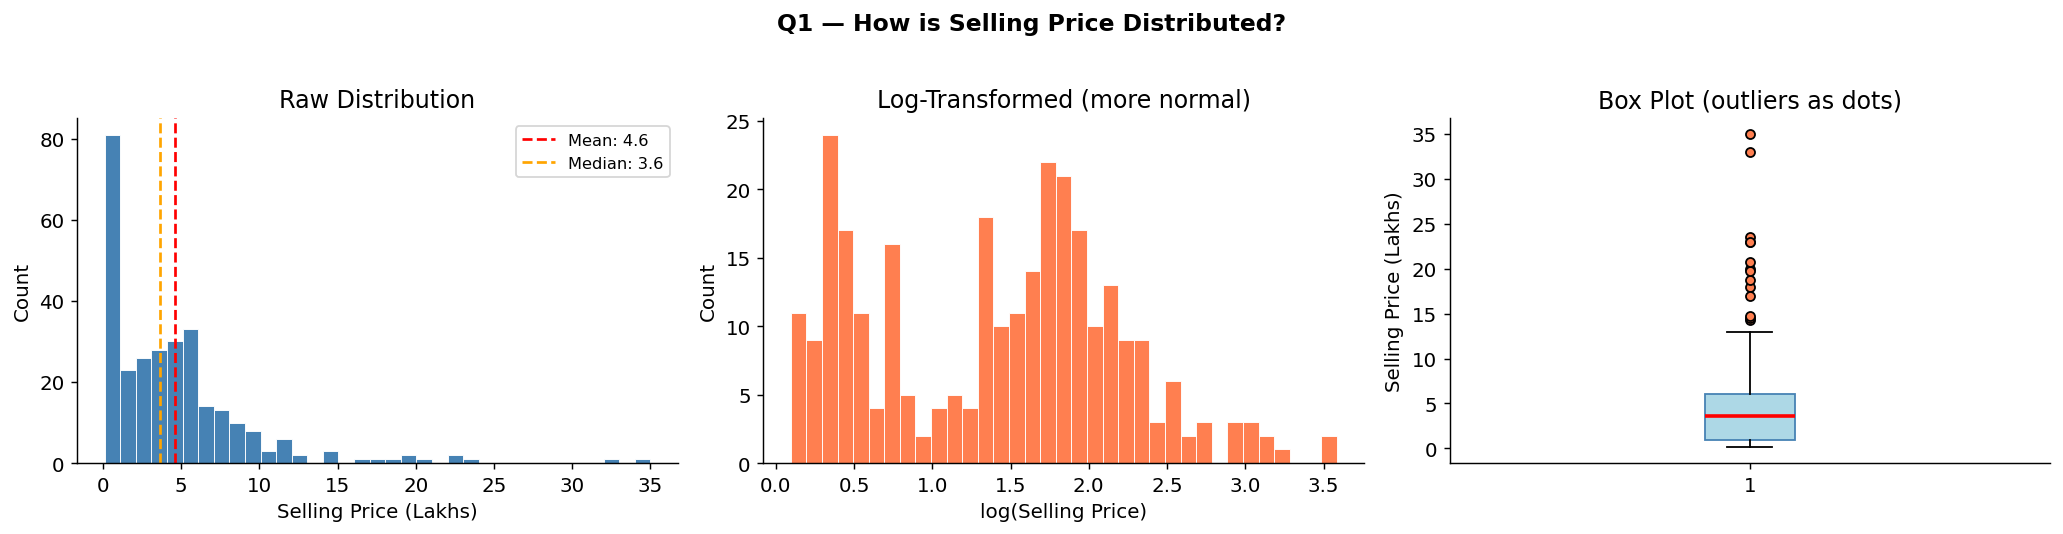

=== Selling Price Statistics ===
Mean:     ₹4.58 Lakhs
Median:   ₹3.65 Lakhs
Std Dev:  ₹4.95 Lakhs
Skewness: 2.61

Conclusion: RIGHT-SKEWED — log transform recommended


In [4]:
print("This is how selling price distributed")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Q1 — How is Selling Price Distributed?', 
             fontsize=13, fontweight='bold', y=1.02)

# --- Plot 1: Raw histogram ---
axes[0].hist(df['Selling_Price'], bins=35, 
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Selling_Price'].mean(), 
                color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['Selling_Price'].mean():.1f}")
axes[0].axvline(df['Selling_Price'].median(), 
                color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['Selling_Price'].median():.1f}")
axes[0].set_title('Raw Distribution')
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# --- Plot 2: Log-transformed histogram ---
axes[1].hist(np.log1p(df['Selling_Price']), bins=35,
             color='coral', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed (more normal)')
axes[1].set_xlabel('log(Selling Price)')
axes[1].set_ylabel('Count')

# --- Plot 3: Box plot (shows spread and outliers) ---
axes[2].boxplot(df['Selling_Price'], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='coral', markersize=5))
axes[2].set_title('Box Plot (outliers as dots)')
axes[2].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('../data/processed/eda_01_price_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# --- Key statistics ---
print("=== Selling Price Statistics ===")
print(f"Mean:     ₹{df['Selling_Price'].mean():.2f} Lakhs")
print(f"Median:   ₹{df['Selling_Price'].median():.2f} Lakhs")
print(f"Std Dev:  ₹{df['Selling_Price'].std():.2f} Lakhs")
print(f"Skewness: {df['Selling_Price'].skew():.2f}")
print(f"\nConclusion: {'RIGHT-SKEWED — log transform recommended' if df['Selling_Price'].skew() > 1 else 'Roughly normal'}")

Car age and how it affects the selling price


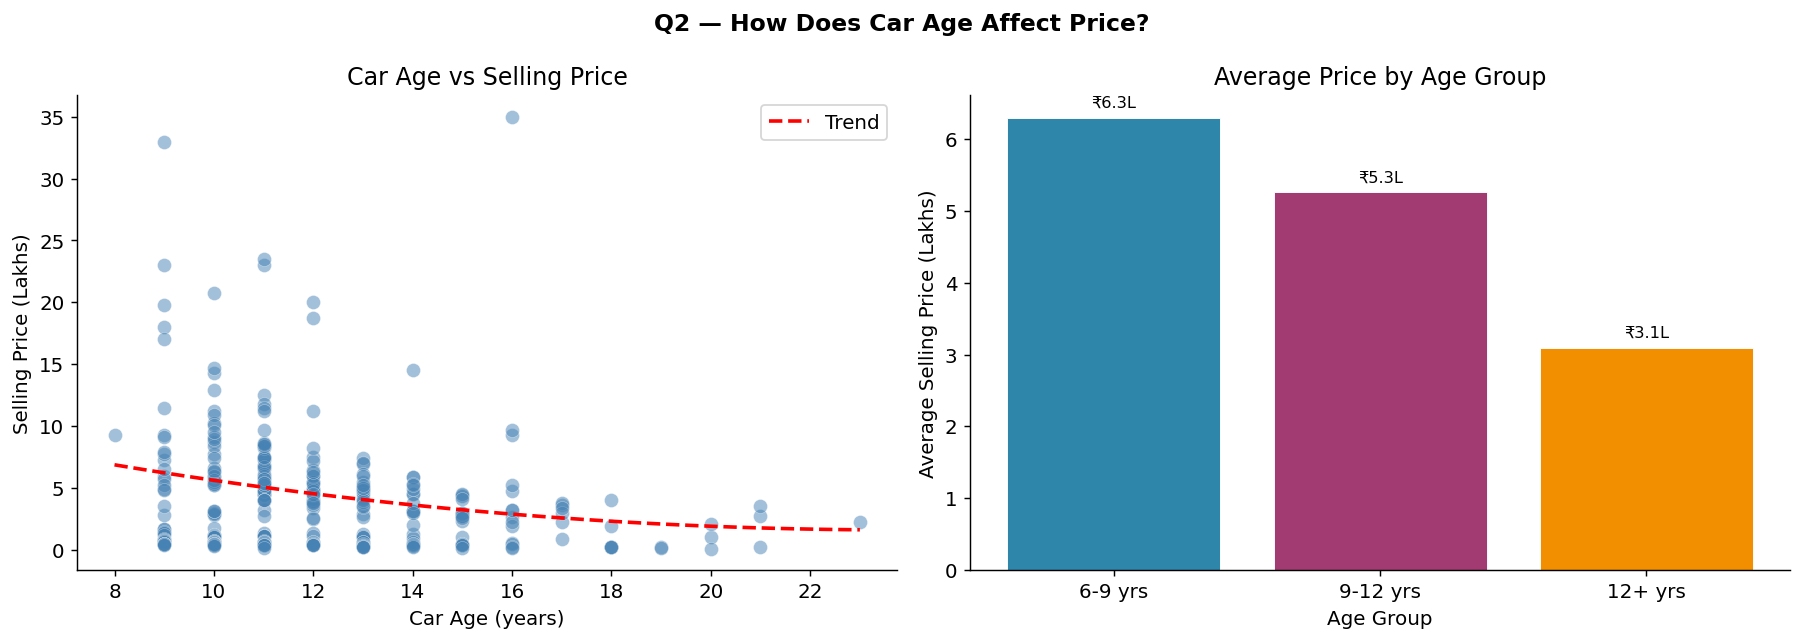

Correlation between Car_Age and Selling_Price: -0.231
(Negative = older cars cost less — expected)


In [5]:
print("Car age and how it affects the selling price")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2 — How Does Car Age Affect Price?', 
             fontsize=13, fontweight='bold')

# --- Plot 1: Scatter plot with regression line ---
axes[0].scatter(df['Car_Age'], df['Selling_Price'],
                alpha=0.5, color='steelblue', edgecolor='white',
                linewidth=0.3, s=60)

# Add a trend line (polynomial fit for curved relationships)
z = np.polyfit(df['Car_Age'], df['Selling_Price'], 2)
p = np.poly1d(z)
x_line = np.linspace(df['Car_Age'].min(), df['Car_Age'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0].set_title('Car Age vs Selling Price')
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Selling Price (Lakhs)')
axes[0].legend()

# --- Plot 2: Average price by age group ---
# Group ages into buckets for clearer pattern
df['Age_Group'] = pd.cut(df['Car_Age'],
                         bins=[0, 3, 6, 9, 12, 100],
                         labels=['0-3 yrs', '3-6 yrs', '6-9 yrs',
                                 '9-12 yrs', '12+ yrs'])

avg_price_by_age = df.groupby('Age_Group', observed=True)['Selling_Price'].mean()

bars = axes[1].bar(avg_price_by_age.index, avg_price_by_age.values,
                   color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B'],
                   edgecolor='white', linewidth=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_price_by_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'₹{val:.1f}L', ha='center', va='bottom', fontsize=9)

axes[1].set_title('Average Price by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('../data/processed/eda_02_age_vs_price.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = df['Car_Age'].corr(df['Selling_Price'])
print(f"Correlation between Car_Age and Selling_Price: {corr:.3f}")
print("(Negative = older cars cost less — expected)")

# Clean up temp column
df = df.drop(columns=['Age_Group'])

This is how fuel type, transmissioin & seller type affect price


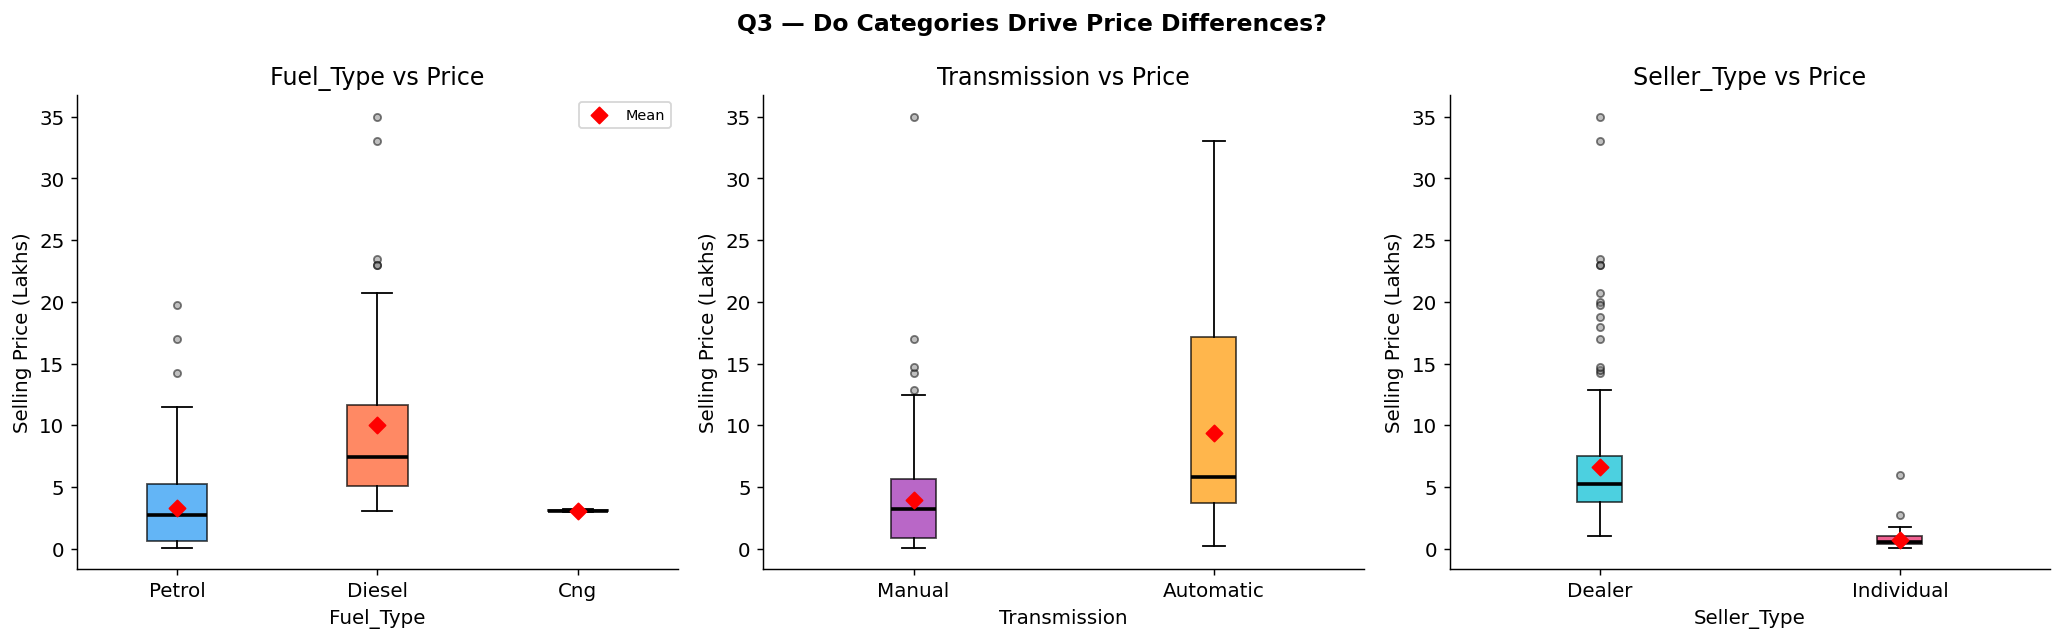

=== Median Selling Price by Category ===

--- Fuel_Type ---
           Median (L)  Mean (L)  Count
Fuel_Type                             
Cng              3.10      3.10      2
Diesel           7.45     10.03     55
Petrol           2.75      3.31    234

--- Transmission ---
              Median (L)  Mean (L)  Count
Transmission                             
Automatic           5.80      9.37     34
Manual              3.25      3.95    257

--- Seller_Type ---
             Median (L)  Mean (L)  Count
Seller_Type                             
Dealer             5.25      6.63    190
Individual         0.52      0.72    101



In [6]:
print("This is how fuel type, transmissioin & seller type affect price")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q3 — Do Categories Drive Price Differences?',
             fontsize=13, fontweight='bold')

cat_features = ['Fuel_Type', 'Transmission', 'Seller_Type']
colors_map = {
    'Fuel_Type':    ['#2196F3', '#FF5722', '#4CAF50'],
    'Transmission': ['#9C27B0', '#FF9800'],
    'Seller_Type':  ['#00BCD4', '#E91E63']
}

for i, feature in enumerate(cat_features):
    categories = df[feature].unique()
    data_to_plot = [df[df[feature] == cat]['Selling_Price'].values 
                    for cat in categories]
    
    bp = axes[i].boxplot(data_to_plot,
                         labels=categories,
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2),
                         flierprops=dict(marker='o', markersize=4,
                                        markerfacecolor='gray', alpha=0.5))
    
    # Colour each box differently
    for patch, color in zip(bp['boxes'], colors_map[feature]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add mean dots
    for j, data in enumerate(data_to_plot):
        axes[i].scatter(j + 1, np.mean(data), 
                       marker='D', color='red', s=40, zorder=5,
                       label='Mean' if j == 0 else '')
    
    axes[i].set_title(f'{feature} vs Price')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Selling Price (Lakhs)')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/eda_03_categories_vs_price.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print median prices per category
print("=== Median Selling Price by Category ===\n")
for feature in cat_features:
    print(f"--- {feature} ---")
    summary = df.groupby(feature)['Selling_Price'].agg(['median', 'mean', 'count'])
    summary.columns = ['Median (L)', 'Mean (L)', 'Count']
    print(summary.round(2))
    print()

How mileage affects price


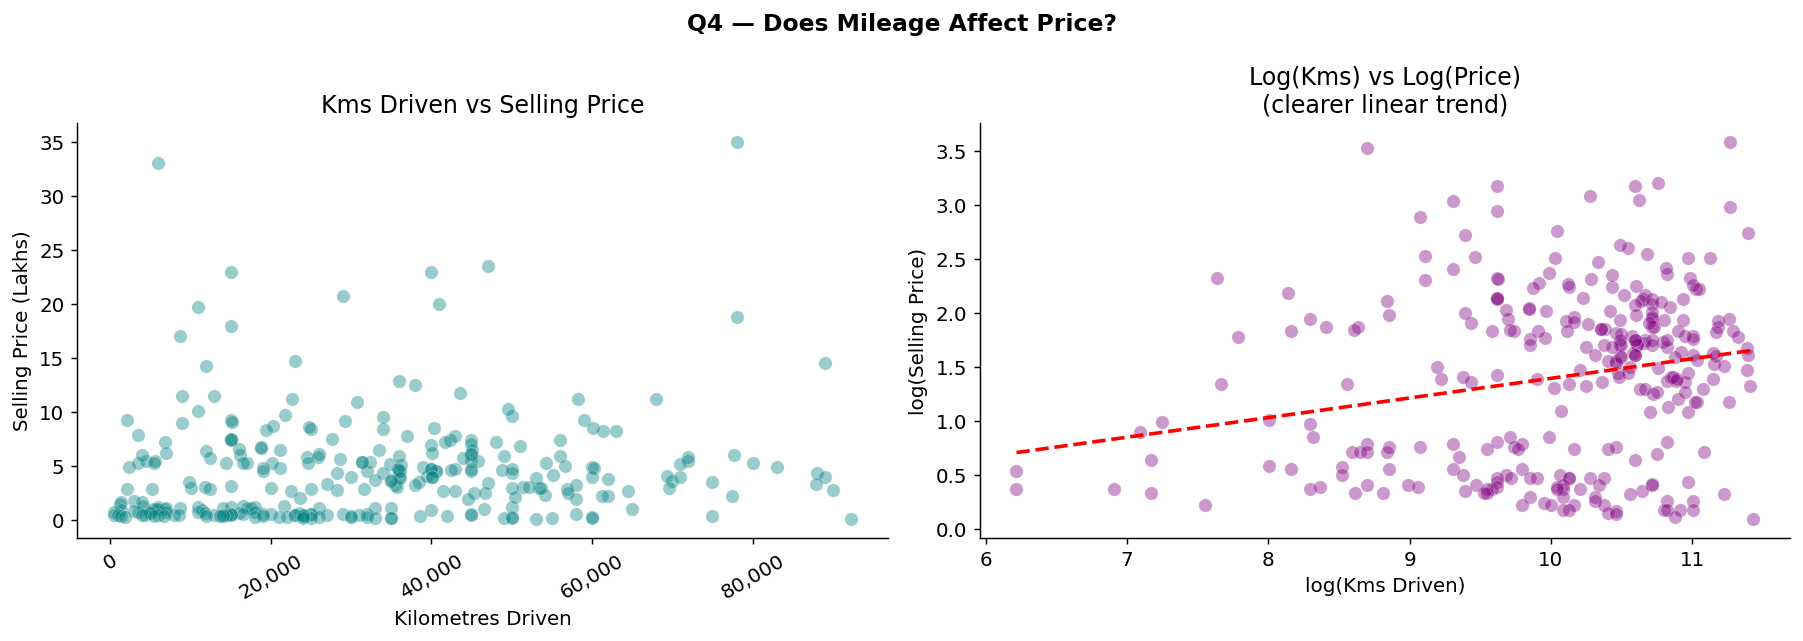

Correlation (raw):     0.120
Correlation (log-log): 0.223

If log-log correlation is stronger, consider log-transforming Kms_Driven


In [7]:
print("How mileage affects price")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q4 — Does Mileage Affect Price?', 
             fontsize=13, fontweight='bold')

# --- Plot 1: Raw scatter ---
axes[0].scatter(df['Kms_Driven'], df['Selling_Price'],
                alpha=0.4, color='teal', edgecolor='white',
                linewidth=0.3, s=55)
axes[0].set_title('Kms Driven vs Selling Price')
axes[0].set_xlabel('Kilometres Driven')
axes[0].set_ylabel('Selling Price (Lakhs)')
# Format x-axis with commas
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# --- Plot 2: Log-log scatter (reveals power relationships) ---
axes[1].scatter(np.log1p(df['Kms_Driven']), np.log1p(df['Selling_Price']),
                alpha=0.4, color='purple', edgecolor='white',
                linewidth=0.3, s=55)

# Regression line on log-log
m, b = np.polyfit(np.log1p(df['Kms_Driven']),
                  np.log1p(df['Selling_Price']), 1)
x_vals = np.linspace(np.log1p(df['Kms_Driven'].min()),
                     np.log1p(df['Kms_Driven'].max()), 100)
axes[1].plot(x_vals, m * x_vals + b, 'r--', linewidth=2)
axes[1].set_title('Log(Kms) vs Log(Price)\n(clearer linear trend)')
axes[1].set_xlabel('log(Kms Driven)')
axes[1].set_ylabel('log(Selling Price)')

plt.tight_layout()
plt.savefig('../data/processed/eda_04_kms_vs_price.png',
            dpi=150, bbox_inches='tight')
plt.show()

corr_raw = df['Kms_Driven'].corr(df['Selling_Price'])
corr_log = np.log1p(df['Kms_Driven']).corr(np.log1p(df['Selling_Price']))
print(f"Correlation (raw):     {corr_raw:.3f}")
print(f"Correlation (log-log): {corr_log:.3f}")
print("\nIf log-log correlation is stronger, consider log-transforming Kms_Driven")

Which car features corelate most with selling price


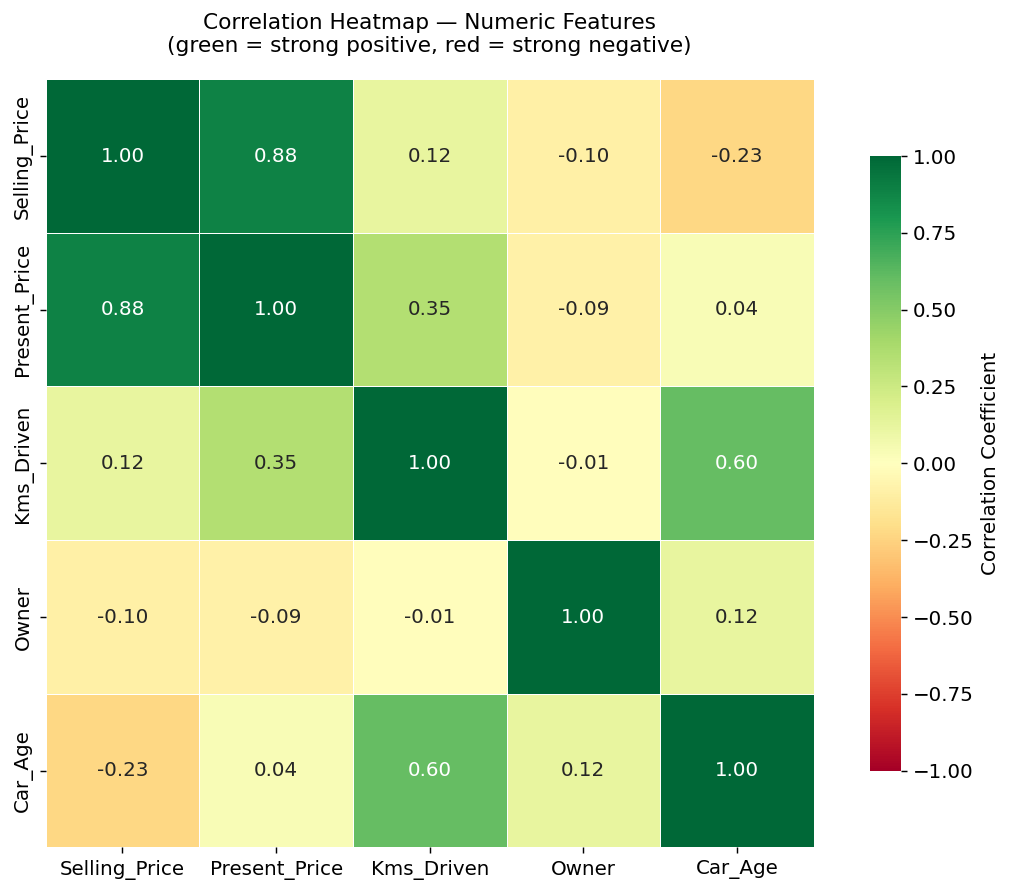

=== Correlations with Selling_Price (sorted) ===

Present_Price       : +0.884  [STRONG positive]
Car_Age             : -0.231  [WEAK negative]
Kms_Driven          : +0.120  [WEAK positive]
Owner               : -0.100  [WEAK negative]


In [8]:
print("Which car features corelate most with selling price")

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# --- Plot: Heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # hide upper triangle

sns.heatmap(corr_matrix,
            annot=True,          
            fmt='.2f',           
            cmap='RdYlGn',       
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numeric Features\n'
             '(green = strong positive, red = strong negative)',
             fontsize=12, pad=15)

plt.tight_layout()
plt.savefig('../data/processed/eda_05_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with Selling_Price, sorted
print("=== Correlations with Selling_Price (sorted) ===\n")
target_corr = corr_matrix['Selling_Price'].drop('Selling_Price').sort_values(
    key=abs, ascending=False)

for feature, corr_val in target_corr.items():
    strength = ('STRONG' if abs(corr_val) > 0.5 
                else 'MODERATE' if abs(corr_val) > 0.3 
                else 'WEAK')
    direction = 'positive' if corr_val > 0 else 'negative'
    print(f"{feature:<20}: {corr_val:+.3f}  [{strength} {direction}]")

PAIRPLOT — SEE EVERY NUMERIC RELATIONSHIP AT A GLANCE
A pairplot shows every feature plotted against every other
Diagonal shows each feature's own distribution


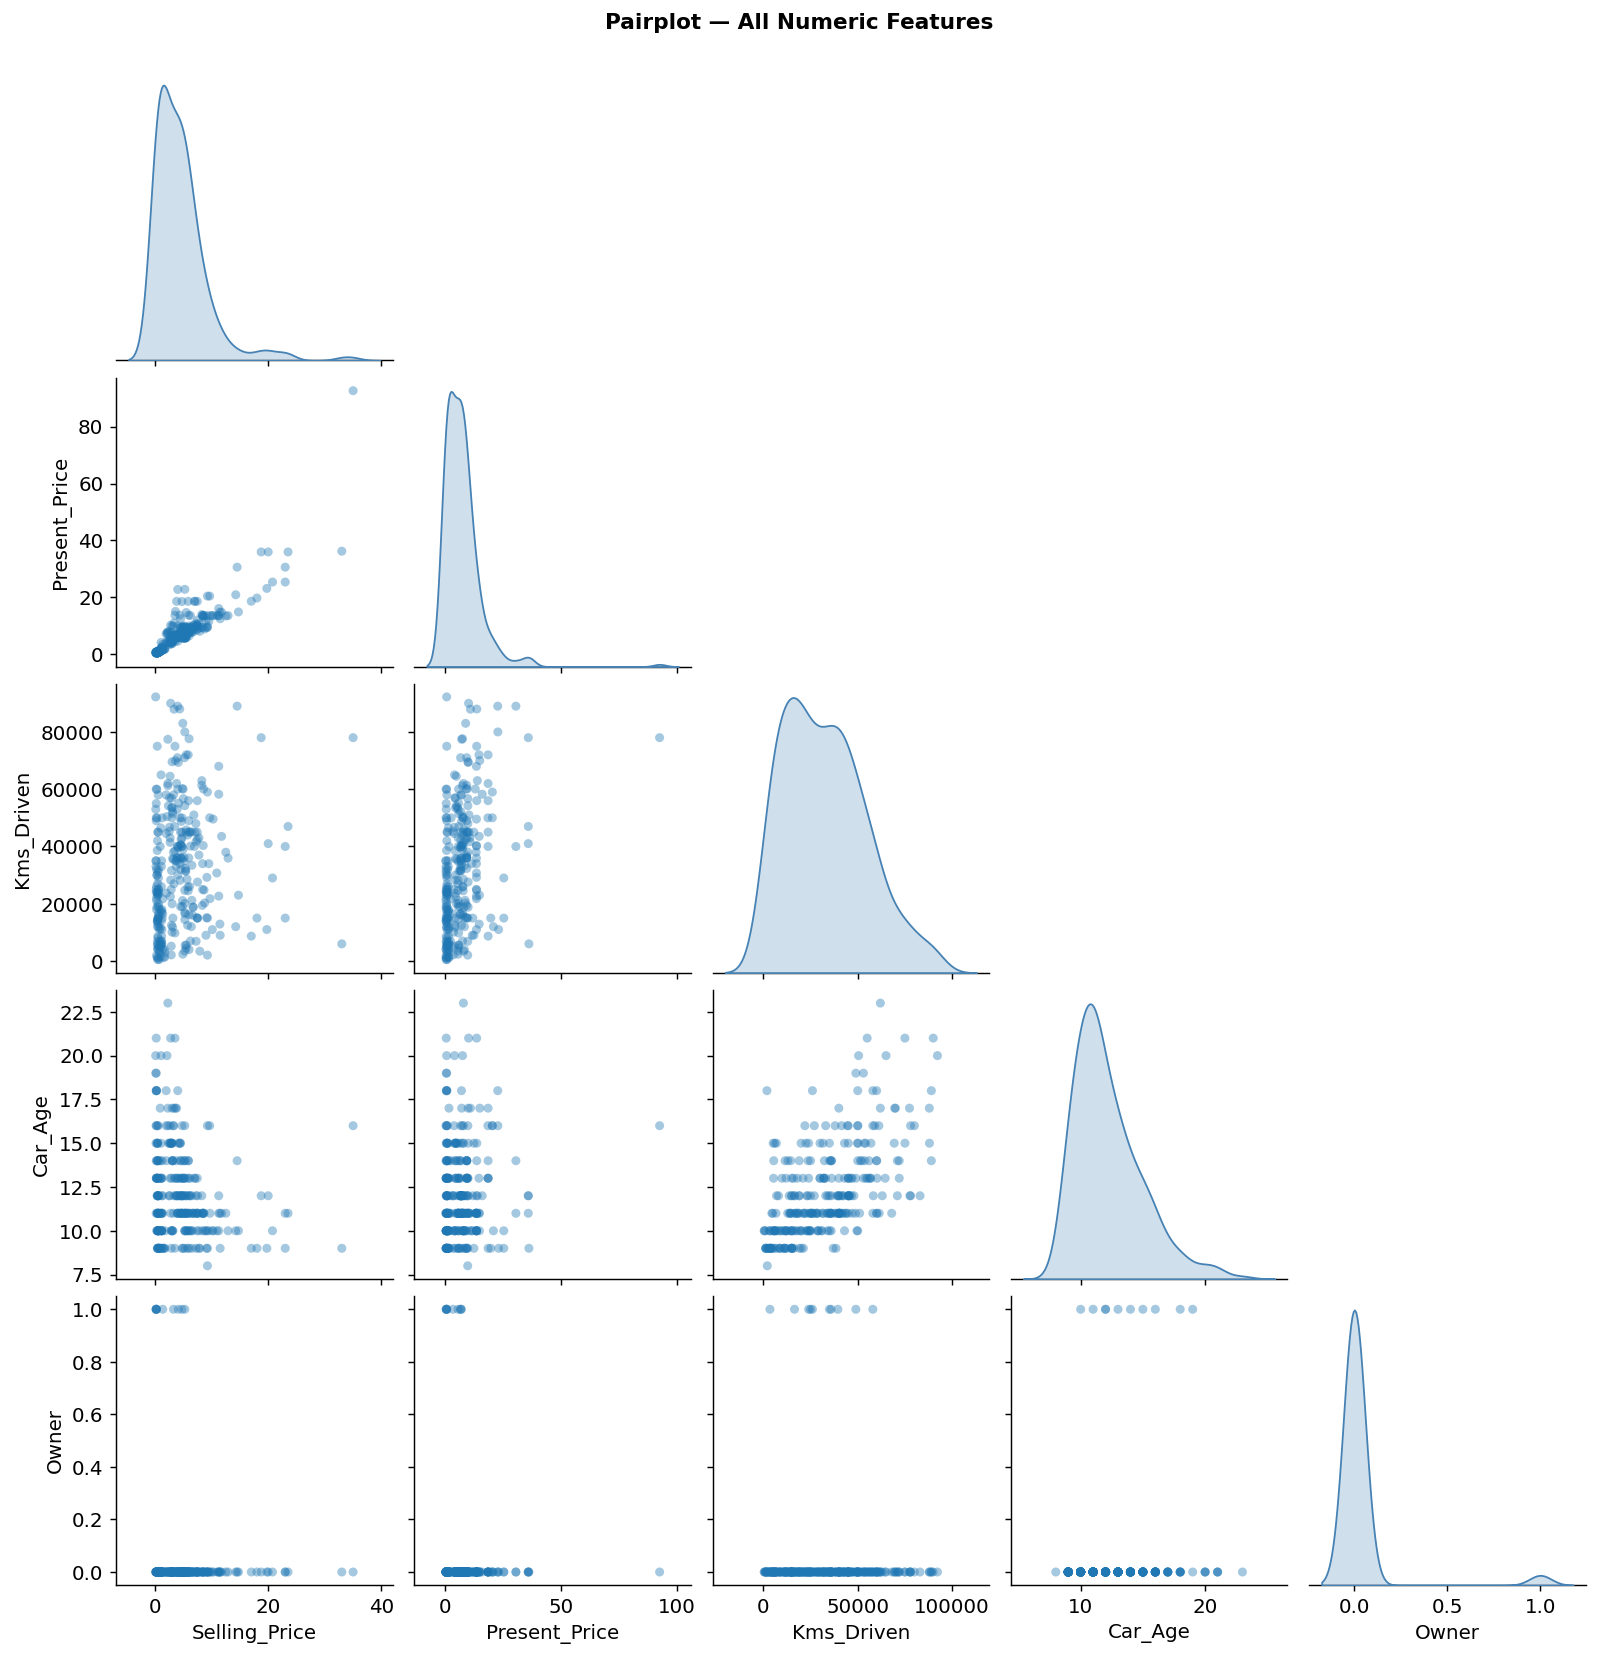

Pairplot saved.


In [10]:
print("PAIRPLOT — SEE EVERY NUMERIC RELATIONSHIP AT A GLANCE")
print("A pairplot shows every feature plotted against every other")
print("Diagonal shows each feature's own distribution")
g = sns.pairplot(
    df[['Selling_Price', 'Present_Price', 'Kms_Driven', 
        'Car_Age', 'Owner']],
    diag_kind='kde',          # smooth distribution on diagonal
    plot_kws={'alpha': 0.4, 'edgecolor': 'none', 's': 25},
    diag_kws={'color': 'steelblue', 'fill': True},
    corner=True               # only show lower triangle (less clutter)
)
g.figure.suptitle('Pairplot — All Numeric Features', 
                  y=1.02, fontsize=12, fontweight='bold')

plt.savefig('../data/processed/eda_06_pairplot.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Pairplot saved.")

INTERACTION EFFECTS — TWO CATEGORIES TOGETHER
Individual categories tell part of the story.
But what about Diesel + Automatic vs Petrol + Manual?
Interaction effects reveal the FULL picture.


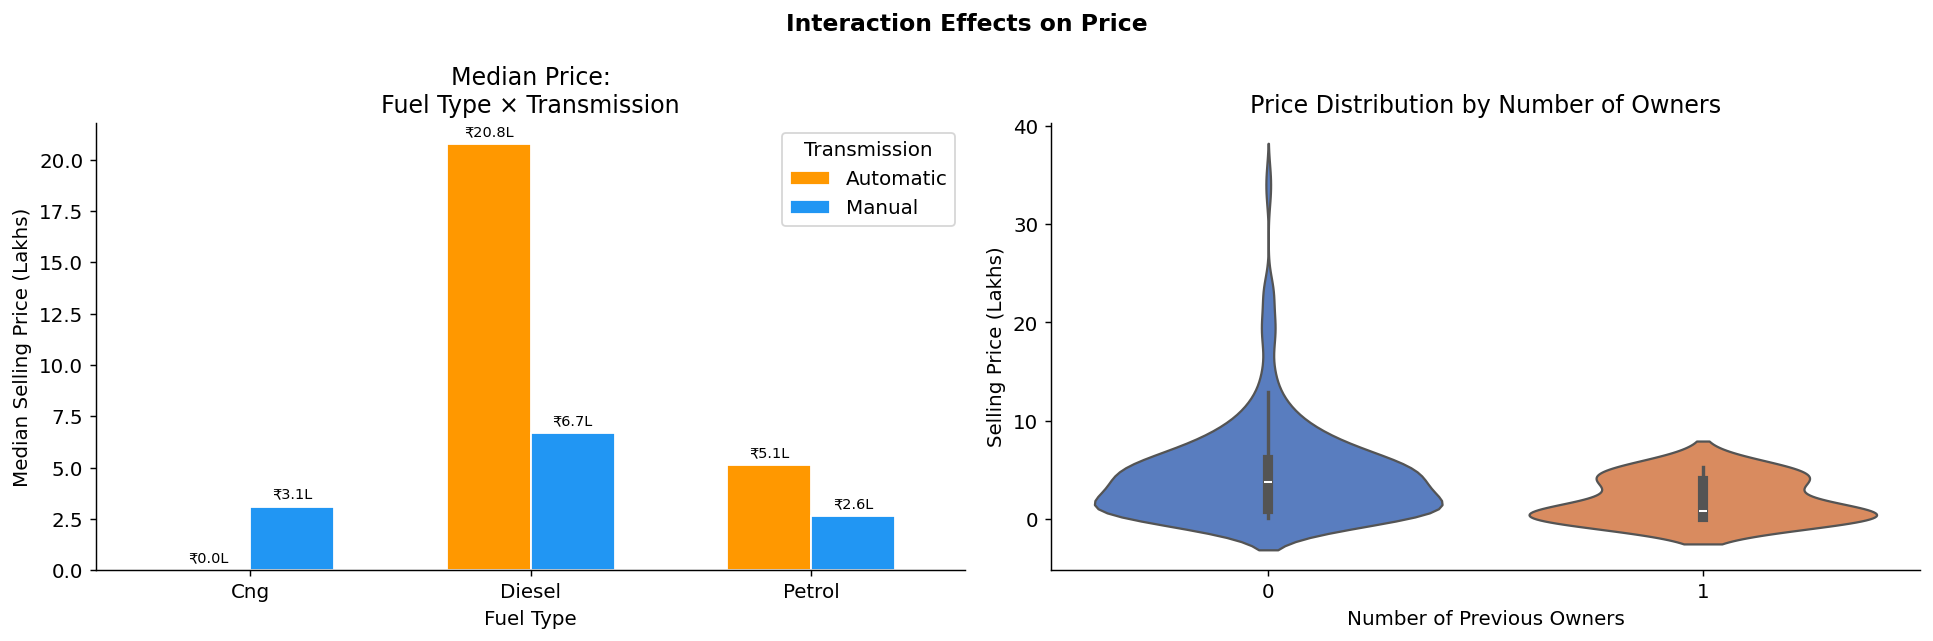

In [11]:
print("INTERACTION EFFECTS — TWO CATEGORIES TOGETHER")

print("Individual categories tell part of the story.")
print("But what about Diesel + Automatic vs Petrol + Manual?")
print("Interaction effects reveal the FULL picture.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Interaction Effects on Price', 
             fontsize=13, fontweight='bold')

# --- Plot 1: Fuel Type × Transmission (grouped bar) ---
interaction = df.groupby(
    ['Fuel_Type', 'Transmission'], observed=True
)['Selling_Price'].median().unstack()

interaction.plot(kind='bar', ax=axes[0],
                 color=['#FF9800', '#2196F3'],
                 edgecolor='white', width=0.6)
axes[0].set_title('Median Price:\nFuel Type × Transmission')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Median Selling Price (Lakhs)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Transmission')

# Value labels
for container in axes[0].containers:
    axes[0].bar_label(container,
                      fmt='₹%.1fL', padding=3, fontsize=8)

# --- Plot 2: Owner count vs price (violin plot) ---
owner_order = sorted(df['Owner'].unique())
sns.violinplot(data=df, x='Owner', y='Selling_Price',
               order=owner_order,
               palette='muted', inner='box', ax=axes[1])
axes[1].set_title('Price Distribution by Number of Owners')
axes[1].set_xlabel('Number of Previous Owners')
axes[1].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('../data/processed/eda_07_interactions.png',
            dpi=150, bbox_inches='tight')
plt.show()

PRESENT PRICE vs SELLING PRICE — THE KEY BUSINESS INSIGHT
Present_Price = what the car costs new today (showroom price)
Selling_Price = what the used car is selling for
Their ratio = depreciation!


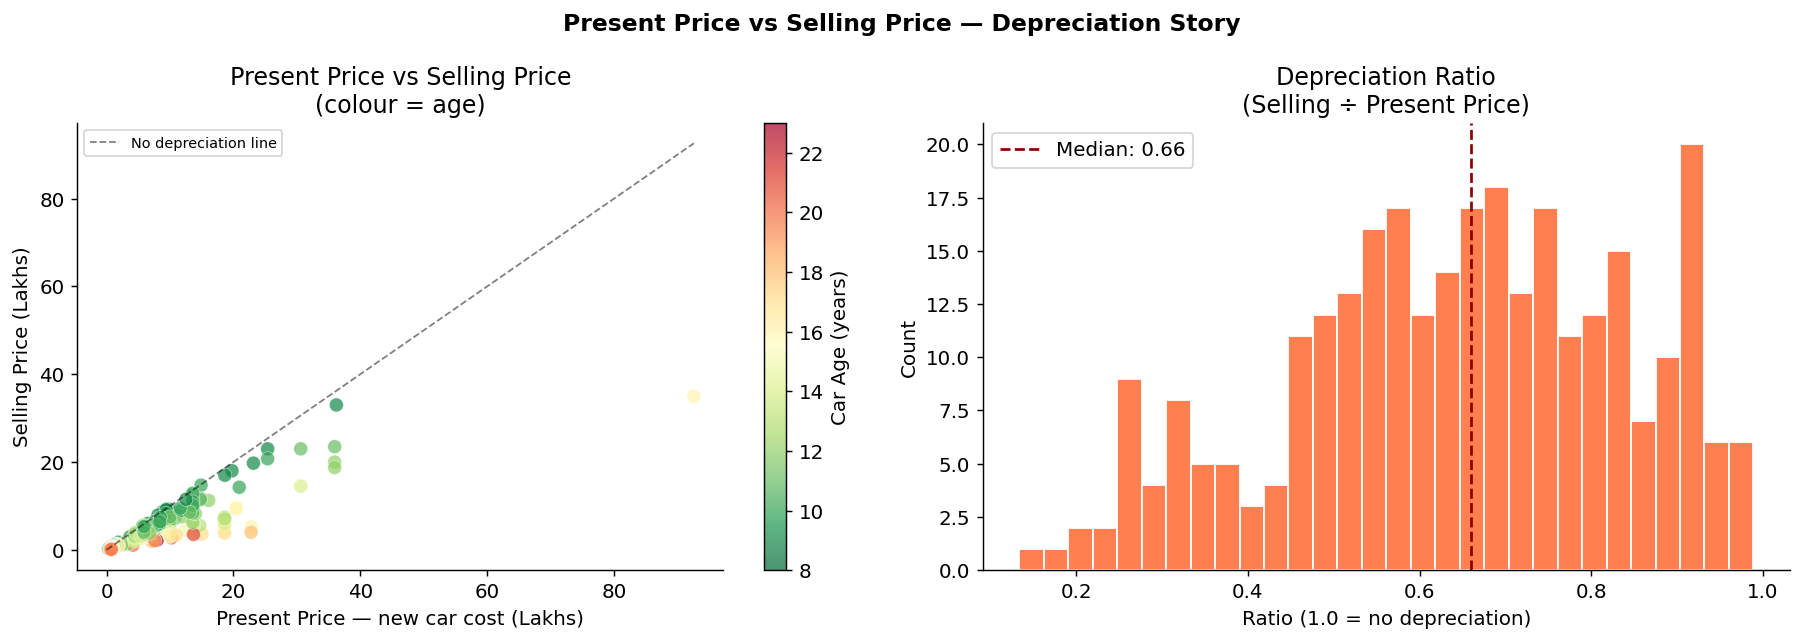

Average depreciation ratio: 0.64
  → Used cars sell for 64% of their new price on average


In [12]:
print("PRESENT PRICE vs SELLING PRICE — THE KEY BUSINESS INSIGHT")

print("Present_Price = what the car costs new today (showroom price)")
print("Selling_Price = what the used car is selling for")
print("Their ratio = depreciation!")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Present Price vs Selling Price — Depreciation Story',
             fontsize=13, fontweight='bold')

# --- Plot 1: Scatter coloured by age ---
scatter = axes[0].scatter(
    df['Present_Price'], df['Selling_Price'],
    c=df['Car_Age'], cmap='RdYlGn_r',
    alpha=0.7, s=60, edgecolor='white', linewidth=0.3
)
plt.colorbar(scatter, ax=axes[0], label='Car Age (years)')

# Perfect 1:1 line (no depreciation)
max_val = max(df['Present_Price'].max(), df['Selling_Price'].max())
axes[0].plot([0, max_val], [0, max_val], 
             'k--', linewidth=1, alpha=0.5, label='No depreciation line')
axes[0].set_title('Present Price vs Selling Price\n(colour = age)')
axes[0].set_xlabel('Present Price — new car cost (Lakhs)')
axes[0].set_ylabel('Selling Price (Lakhs)')
axes[0].legend(fontsize=8)

# --- Plot 2: Depreciation ratio distribution ---
df['Depreciation_Ratio'] = df['Selling_Price'] / df['Present_Price']
axes[1].hist(df['Depreciation_Ratio'], bins=30,
             color='coral', edgecolor='white')
axes[1].axvline(df['Depreciation_Ratio'].median(),
                color='darkred', linestyle='--',
                label=f"Median: {df['Depreciation_Ratio'].median():.2f}")
axes[1].set_title('Depreciation Ratio\n(Selling ÷ Present Price)')
axes[1].set_xlabel('Ratio (1.0 = no depreciation)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/eda_08_depreciation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Average depreciation ratio: {df['Depreciation_Ratio'].mean():.2f}")
print(f"  → Used cars sell for {df['Depreciation_Ratio'].mean()*100:.0f}% of their new price on average")

# Drop the temp column
df = df.drop(columns=['Depreciation_Ratio'])

In [13]:
print("""
╔══════════════════════════════════════════════════════════╗
║           EDA FINDINGS SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  TARGET (Selling_Price)                                  ║
║  • Right-skewed — log transform recommended              ║
║  • Range: ~0.1L to ~35L, median ~4-5L                    ║
║                                                          ║
║  STRONGEST PREDICTORS (from correlation heatmap)         ║
║  1. Present_Price   — strong positive correlation        ║
║  2. Car_Age         — strong negative correlation        ║
║  3. Kms_Driven      — moderate negative correlation      ║
║                                                          ║
║  CATEGORICAL INSIGHTS                                    ║
║  • Diesel > Petrol in median price                       ║
║  • Automatic > Manual in median price                    ║
║  • Dealer listings > Individual listings in price        ║
║  • 0 previous owners commands highest prices             ║
║                                                          ║
║  DATA QUALITY                                            ║
║  • No missing values                                     ║
║  • A few high-price outliers (real luxury cars, keep)    ║
║  • CNG cars are very rare — small sample                 ║
║                                                          ║
║  MODEL IMPLICATIONS                                      ║
║  • Log-transform Selling_Price before training           ║
║  • Present_Price will likely be the top feature          ║
║  • Consider log-transforming Kms_Driven too              ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           EDA FINDINGS SUMMARY                           ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  TARGET (Selling_Price)                                  ║
║  • Right-skewed — log transform recommended              ║
║  • Range: ~0.1L to ~35L, median ~4-5L                    ║
║                                                          ║
║  STRONGEST PREDICTORS (from correlation heatmap)         ║
║  1. Present_Price   — strong positive correlation        ║
║  2. Car_Age         — strong negative correlation        ║
║  3. Kms_Driven      — moderate negative correlation      ║
║                                                          ║
║  CATEGORICAL INSIGHTS                                    ║
║  • Diesel > Petrol in median price                       ║
║  • Automatic > Manual in median price                    ║
║  • Dealer listings > 

In [15]:
print("All EDA VISUAL REPORT in one PDF")
from matplotlib.backends.backend_pdf import PdfPages
import os

chart_files = [
    '../data/processed/eda_01_price_distribution.png',
    '../data/processed/eda_02_age_vs_price.png',
    '../data/processed/eda_03_categories_vs_price.png',
    '../data/processed/eda_04_kms_vs_price.png',
    '../data/processed/eda_05_correlation_heatmap.png',
    '../data/processed/eda_06_pairplot.png',
    '../data/processed/eda_07_interactions.png',
    '../data/processed/eda_08_depreciation.png',
]

with PdfPages('../data/processed/EDA_Report.pdf') as pdf:
    for chart_path in chart_files:
        if os.path.exists(chart_path):
            img = plt.imread(chart_path)
            fig, ax = plt.subplots(figsize=(11, 8))
            ax.imshow(img)
            ax.axis('off')
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

print("EDA Report saved to: data/processed/EDA_Report.pdf")

All EDA VISUAL REPORT in one PDF
EDA Report saved to: data/processed/EDA_Report.pdf
